<div style="text-align: center">
    <img src="./images/markdown//assets/uofg_blue.png" alt="PHYS5036" width="800">
    <p style="text-align: center;"><strong>Welcome to PHYS5036. </strong>
Detection and Analysis of Ionising Radiation
    </p>
</div>

In [4]:
# Importing the required modules
import pandas as pd                 # Common python dataframe package used in industry and academia
import matplotlib.pyplot as plt     # Common python package for plotting
from pathlib import Path

# <b>Analysis of Dose Distributions in Radiotherapy Experiment</b>

This is a <b>computational-based experiment</b> using a Monte-Carlo physics simulation software called Geant4.

In nuclear and particle physics research, it is very common to perform physics simulations to refine methods and demonstrate feasibility before costly experimental tests.

One sub-field of cutting-edge research is in beam radiotherapy, where <b>gamma, electron, proton and ion beams </b> can be used to target cancerous regions.

The aim of this virtual experiment is to investigate how beams of different particles types and different energies deposit energy in a simplified setup using a water phantom.

**Objectives:**
1. To gain an understanding of the electromagnetic interactions of high-energy gamma-rays, electrons, protons and ions and relate the range of these particle types in matter to their underlying interactions.
2. To understand the relationship between deposited energy, absorbed dose and equivalent dose.
3. To become familiar with secondary particle interactions and hadronic processes and directly relate them to radiotherapy applications.
4. To gain an appreciation of the differences in dose distributions in targeting cancer with different beam types.

## <span style="color:red">Software Installation Instructions</span>

<I>You <b>must</b> complete this step before proceeding with the lab. Please ask a demonstrator <b>as soon as possible</b> if you run into any issues.</I>

Before we can start investigating radiotherapy with different beam types, the software must first be downloaded, set up correctly and compiled on the School's UNIX teaching server.


1. Follow the steps in the “[First Computing Set Up Steps](https://moodle.gla.ac.uk/mod/resource/view.php?id=5712449)” document, found on the Lab Moodle page, under the Lab Material ➔ Computing section. It provides some useful introductory reading for using the School’s
computing.

    Once you are happy with that document, [log into JupyterHub](https://jupyter.physics.gla.ac.uk/hub/login) in the normal way (remember if you are working remotely, you will need to first connect via VPN). 


2. Then follow the environment set up instructions in Section 2 of the “[Experiment Computing Set Up](https://moodle.gla.ac.uk/mod/resource/view.php?id=5712464)” document from on the Lab Moodle page, under the Lab Material ➔ Computing section. 

    If you have any questions during this setup stage speak to the lab staff, who are happy to help you.

    When we execute the command `bash /local/cern/software/Sim/SoftwareSetup.sh` during the Experiment Computing Set Up, we are telling your UNIX environment how to find the relevant simulation code. This is a Geant4 particle transport Monte Carlo simulation called DoseProfileMC which has been designed specifically for this laboratory.



<br>

<span style="color:red">Advanced: </span> For students interested in the Geant4 software details, the C++ class definition files can be found on Moodle in the Computing section, in a folder called “[DoseProfileMC Source Code](https://moodle.gla.ac.uk/mod/url/view.php?id=5712954)” Have a look at the folders and files inside. The class implementation files are in `DoseProfileMC/src/` subdirectory. Look through these classes if you are curious how the C++ code for a Geant4 simulation is run and ask if you have any questions. The physical geometry of the setup is defined in `src/DetectorConstruction.cc`.

User control of the simulation can be implemented by editing text files like those found in the `macros/` subdirectory: `DetectorSetup.mac`, `vis.mac` and `batch.mac`. Have a look at the commands in these files if you are interested in how Geant4 is run.

## <b>Background Physics </b>

<b>Before</b> starting this lab, it is <b><i>highly recommended</i></b> to have a read of the [background material](https://moodle.gla.ac.uk/pluginfile.php/11130450/mod_resource/content/3/PHYS5036_IntroLecture_091025.pdf) on the moodle page. You will be working with gamma rays and heavy charged particles (protons, C-12 ions), so refer to the relevant sections on how each of these particle types interact with matter to help you interpret your results. Also provided in this document is some information on Monte-Carlo generators.

It is further encouraged you do some background research of your own and converse with the demonstrators for further understanding of aspects related to the lab outwith this material.

<b>Questions:</b>
- What are the three main types of interactions that gamma rays can have with matter, and how do these interactions depend on the energy of the gamma rays?
- How do light and heavy charged particles interact with matter, and how does this depend on their energy?
- What are the main benefits of using Monte-Carlo simulations over an experimental approach?
- How does Geant4 reliably simulate particle interactions with matter, how is this deterministically performed, and what role do random numbers play in the simulation? Hint: This may require some extra reading on the Monte-Carlo method and the implementation details of Geant4.

## <b>Introduction: Radiotherapy for Cancer Treatment</b>

More and more treatment plans for cancer patients involve the use of radiotherapy, in which a beam of high-energy subatomic particles is used to cause catastrophic cell damage in cancerous tumours. The damage is done at the DNA level through microscopic interactions in which the beam particles transfer energy to the tumour tissue causing bonds to be broken and eventually cellular death. In order that the dose to which the tumour is exposed is much larger than the dose received by healthy tissue, treatment plans normally involve
the use of shaped beams targeting the tumour area from several different orientations as shown in Figure 1. 

While the effectiveness of such treatment has been demonstrated in the clinical setting, there is a large international research effort into using different types of beams. Much of the motivation for this research is due to the need to further minimise the damage caused to healthy tissue during these types of treatments.

There has therefore been a paradigm shift away from the use of high-energy gamma-ray beams to the use of hadron (proton or heavy ion) beams. Indeed, the NHS in England is in the process of developing two new hadron therapy treatment facilities. The shift from gamma to hadron beams is intimately connected to the nature in which these different particles interact and deposit dose in the patient. The motivation for the current virtual experiment is exploring the relevant particle interactions in this radiotherapy context.

<div style="text-align: center">
    <img src="./images/markdown/doseTherapy_GammaSetup.png" alt="Annotated CS-137 spectrum" width="700">
    <p style="text-align: center;"><strong>Figure 1:</strong> An example showing the use of several beam shapes, orientations and intensities. Taken from http://www.aafp.org/afp/2008/1201/p1254.html .</p>
</div>

***
## <b>Part One: The Electromagnetic Interactions of Gamma rays</b>
***

The energy-loss process for high-energy gamma-rays or charged particles is dominated by <b>electromagnetic interactions</b> between the incident particle and atomic electrons in matter. The nature of these interactions is dependent on particle type (charge and mass) and energy. In radiotherapy, it is these electromagnetic interactions that play by far the largest part in governing the nature in which energy is transferred from the beam particle to the patient.

We will investigate the energy dependence of the electromagnetic interactions for the four different beam types of interest (gamma-rays, electrons, protons and ions) by simulating a beam incident on a water phantom.

To begin with we will generate a beam of <b>1 MeV gamma-rays</b>. This is a good starting point as radiotherapy is currently dominated globally by treatment plans and technologies involving high energy gamma-rays.

### 1.1 Running your First Simulation

Create a data directory and run the first simulation in a UNIX terminal:

```bash
mkdir -p ~/data
cd ~/data
runDoseProfile.py gamma 1 10000 0 0
```

The command uses a 1 MeV gamma beam, 10,000 incident particles, no tumour, and electromagnetic physics only. The output CSV should be available in the directory configured by `OUTPUT_DIR`.

The visualisation shown in Figure 2 is provided as a reference; it is not run through JupyterHub. The gamma beam travels along the -y direction. The transverse direction is the x-z plane, and the longitudinal direction is the y-axis.

![Example Geant4 visualisation](./images/markdown/doseTherapy_Geant4Vis.png)

**Questions**

1. Based on Figure 2, what observations can be made about the interaction between the beam and the phantom?
2. Using your background knowledge of gamma-ray interactions with matter, explain why the tracks appear differently at different energies.


### 1.2 Analysing the Simulated Data

It is of course important to be more rigorous in these investigations than simply visualising the interactions of a handful of gamma-rays. We do this by investigating in detail how energy is deposited in the phantom by analysing the simulated data using python.

The output from the simulation is written to the directory specified by `OUTPUT_DIR`. For the example command above, the filename is `DoseMC_gamma_1MeV_10000n_Out.csv`. Opening the csv file may be slow, since it is a lot of data. Opening the csv file may be slow, since it is a lot of data. In the simulation, the phantom is split up into cubic volume elements (voxels) in order to discretise the data. Figure 3 below shows a visualisation of how the voxel grid is setup in the phantom.

The csv file records the energy deposited in each voxel, as well as the type of particle(s) which deposited the energy. Ignore the columns referring to “T” for the moment, these will become apparent later in the script. Figure 3 below shows a visualisation of where the voxel grid is defined in the phantom.

<div style="text-align: center">
    <img src="./images/markdown/doseTherapy_Voxelisation.png" alt="voxelisation" width="600">
    <p style="text-align: center;"><strong>Figure 3:</strong> Geant4 visualiser window of the phantom, overlaid with an <b><i>approximation</i></b> of how the voxel grid is defined.</p>
</div>


We have provided some code within this notebook to help you get started with the analysis. You can modify and expand this code however you wish. This includes a read-in function alongside some analysis/plotting functions of the data in the below sub-sections.

#### 1.2.1 Reading in the Data

In [5]:
def read_process_csv(fileName):

    # First, we read the header of the csv file to get metadata
    header = pd.read_csv(fileName,nrows=1)

    
    xbins  = header["xbins"][0]
    xmin   = header["xmin"][0]
    xmax   = header["xmax"][0]

    ybins  = header["ybins"][0]
    ymin   = header["ymin"][0]
    ymax   = header["ymax"][0]

    zbins  = header["zbins"][0]
    zmin   = header["zmin"][0]
    zmax   = header["zmax"][0]

    bins = [xbins, ybins, zbins]
    rangemin = [xmin, ymin, zmin]
    rangemax = [xmax, ymax, zmax]

    intnev   = header["nevent"][0]
    particle = header["particle"][0]
    energy   = header["energy"][0]

    # Second, we read the data of the csv file and organise into a Pandas Dataframe
    dataframe = pd.read_csv(fileName,skiprows=2)
    dataframe["sum"]     = dataframe["lepton"]+dataframe["meson"]+dataframe["baryon"]+dataframe["ion"]
    dataframe["sumT"]    = dataframe["leptonT"]+dataframe["mesonT"]+dataframe["baryonT"]+dataframe["ionT"]
    dataframe["leptonA"] = dataframe["lepton"]+dataframe["leptonT"]
    dataframe["mesonA"]  = dataframe["meson"]+dataframe["mesonT"]
    dataframe["baryonA"] = dataframe["baryon"]+dataframe["baryonT"]
    dataframe["ionA"]    = dataframe["ion"]+dataframe["ionT"]
    dataframe["Total"]   = dataframe["sum"]+dataframe["sumT"]
    dataframe["xpos"]    = xmin+(0.5+dataframe["x"])*(xmax-xmin)/xbins
    dataframe["ypos"]    = ymin+(0.5+dataframe["y"])*(ymax-ymin)/ybins
    dataframe["zpos"]    = zmin+(0.5+dataframe["z"])*(zmax-zmin)/zbins
    
    return dataframe, intnev, particle, energy, bins, rangemin, rangemax

#### 1.2.2 Dose Profile by Particle Type

The `plot_components_as_hist` function creates a histogram (frequency distribution) of deposited energy for different particle types. The particle type in this case refers to the particle which deposited the energy and an be either lepton, meson, baryon or ion.

The `calculate_energy_by_particle` function calculates the fraction of the total energy deposited by each particle type and prints out the energies deposited by the particles. 

In [6]:
def simulation_tag(filename):
    """Return a filename-safe tag derived from a simulation CSV path."""
    return Path(filename).stem.replace('DoseMC_', '')


def plot_components_as_hist(dataframe, nbins=100, savefig=False, tag=''):
    # Plot deposited energy by particle type.
    erange = 0, dataframe["Total"].max()

    plt.figure(figsize=(15, 10))
    dataframe['leptonA'].hist(bins=nbins, range=erange, color='black', alpha=0.5, label='Leptons')
    dataframe['mesonA'].hist(bins=nbins, range=erange, color='red', alpha=0.5, label='Mesons')
    dataframe['baryonA'].hist(bins=nbins, range=erange, color='blue', alpha=0.5, label='Baryons')
    dataframe['ionA'].hist(bins=nbins, range=erange, color='magenta', alpha=0.5, label='Ions')
    plt.xlabel('Energy Deposited (MeV)')
    plt.legend()
    plt.yscale('log')

    if savefig:
        filename = f'DoseByParticle_{tag}.pdf' if tag else 'DoseByParticle.pdf'
        plt.savefig(filename, bbox_inches='tight')
    plt.show()


def calculate_energy_by_particle(dataframe, intnev, particle, energy):
    # Calculate energy deposited by each particle type.
    print('For', intnev, 'incident', particle, 'with an energy of', energy, 'MeV')
    calc_total = dataframe['Total'].sum()
    print('Calculated total energy deposited by leptons, mesons, baryons and ions ', calc_total, 'MeV')

    for column, label in [
        ('leptonA', 'leptons'),
        ('mesonA', 'mesons'),
        ('baryonA', 'baryons'),
        ('ionA', 'ions'),
    ]:
        deposited = dataframe[column].sum()
        print(f'Fraction of energy deposited by {label} = ', deposited / calc_total * 100, ' %')

### 1.2.3 Longitudinal Dose Profile

This `plot_longitudinal_profile' function plots a 1-D distribution of energy deposited in a central slice through the phantom in the longitudinal (parallel to the beam) direction.

In [7]:
def plot_longitudinal_profile(dataframe, bins, rangemin, rangemax,
                              intnev, savefig=False, tag=''):
    rangey = (rangemin[1], rangemax[1])
    ybins = int(bins[1])

    cutframeL = dataframe[
        (dataframe['zpos'].abs() < 10) &
        (dataframe['xpos'].abs() < 10)
    ]

    plt.figure(figsize=(15, 10))
    plt.hist(
        cutframeL['ypos'], weights=cutframeL['sum'] / intnev,
        bins=ybins, range=rangey, alpha=0.5, label='Normal'
    )
    plt.hist(
        cutframeL['ypos'], weights=cutframeL['sumT'] / intnev,
        bins=ybins, range=rangey, alpha=0.5, label='Tumour'
    )
    plt.xlabel('Longitudinal Position (mm)')
    plt.ylabel('Energy deposited per incident particle (MeV)')
    plt.legend()

    if savefig:
        filename = f'LongitudinalProfile_{tag}.pdf' if tag else 'LongitudinalProfile.pdf'
        plt.savefig(filename, bbox_inches='tight')
    plt.show()

    total_sum = cutframeL['sum'].sum() + cutframeL['sumT'].sum()
    mean_voxel_energy = total_sum / (intnev * ybins)
    print('Mean energy deposited per voxel in longitudinal direction ',
          mean_voxel_energy, 'MeV per voxel')

    normal_sum = cutframeL['sum'].sum()
    tumour_sum = cutframeL['sumT'].sum()
    if normal_sum:
        print('TNR is ', tumour_sum / normal_sum)
    else:
        print('TNR is undefined because the normal-tissue dose is zero')

### 1.2.4 Transverse Dose Profile

Below are the functions for plotting the 1-D and 2-D distributions of energy deposited in a central slice through the phantom in the transverse (perpendicular to the beam) direction.

In [8]:
def plot_transverse_profile(dataframe, bins, rangemin, rangemax,
                            intnev, savefig=False, tag=''):
    rangex = rangemin[0], rangemax[0]
    xbins = int(bins[0])
    zbins = int(bins[2])

    cutframeT = dataframe[dataframe['ypos'].abs() < 10]

    plt.figure(figsize=(15, 10))
    plt.hist(
        cutframeT['xpos'], weights=cutframeT['sum'] / intnev,
        bins=xbins, range=rangex, alpha=0.5, label='Normal'
    )
    plt.hist(
        cutframeT['xpos'], weights=cutframeT['sumT'] / intnev,
        bins=xbins, range=rangex, alpha=0.5, label='Tumour'
    )
    plt.xlabel('Transverse Position (mm)')
    plt.ylabel('Energy deposited per incident particle (MeV)')
    plt.legend()

    if savefig:
        filename = f'TransverseProfile_{tag}.pdf' if tag else 'TransverseProfile.pdf'
        plt.savefig(filename, bbox_inches='tight')
    plt.show()

    total_sum = cutframeT['sum'].sum() + cutframeT['sumT'].sum()
    mean_voxel_energy = total_sum / (intnev * zbins)
    print('Mean energy deposited per voxel in transverse direction ',
          mean_voxel_energy, 'MeV per voxel')


def plot_2d_transpose_profile(dataframe, bins, rangemin, rangemax,
                              savefig=False, tag=''):
    xbins = int(bins[0])
    zbins = int(bins[2])
    rangexz = ([rangemin[0], rangemax[0]], [rangemin[2], rangemax[2]])

    plt.figure(figsize=(20, 15))
    plt.hist2d(
        x=dataframe['xpos'], y=dataframe['zpos'], weights=dataframe['Total'],
        bins=(xbins, zbins), range=rangexz, cmap=plt.cm.jet
    )
    cbar = plt.colorbar()
    plt.xlabel('X Position (mm)')
    plt.ylabel('Z Position (mm)')
    cbar.ax.set_ylabel('Energy deposited (MeV)')

    if savefig:
        filename = f'TransverseProfile2D_{tag}.pdf' if tag else 'TransverseProfile2D.pdf'
        plt.savefig(filename, bbox_inches='tight')
    plt.show()


# Backwards-compatible alias for the original notebook name.
plot_transpose_profile = plot_transverse_profile

### 1.3 Analysis of the 1 MeV Gamma-ray Beam

Use the functions provided in Section 1.2 to analyse the 1 MeV gamma-ray simulation.

**Questions**

1. What can you say about the magnitude of energy deposited in the phantom?
2. How is the deposited energy distributed longitudinally and transversely?
3. How do these observations relate to the underlying gamma-ray interactions?


For 10000 incident gamma with an energy of 1 MeV
Calculated total energy deposited by leptons, mesons, baryons and ions  3761.9221963106997 MeV
Fraction of energy deposited by leptons =  100.0  %
Fraction of energy deposited by mesons =  0.0  %
Fraction of energy deposited by baryons =  0.0  %
Fraction of energy deposited by ions =  0.0  %


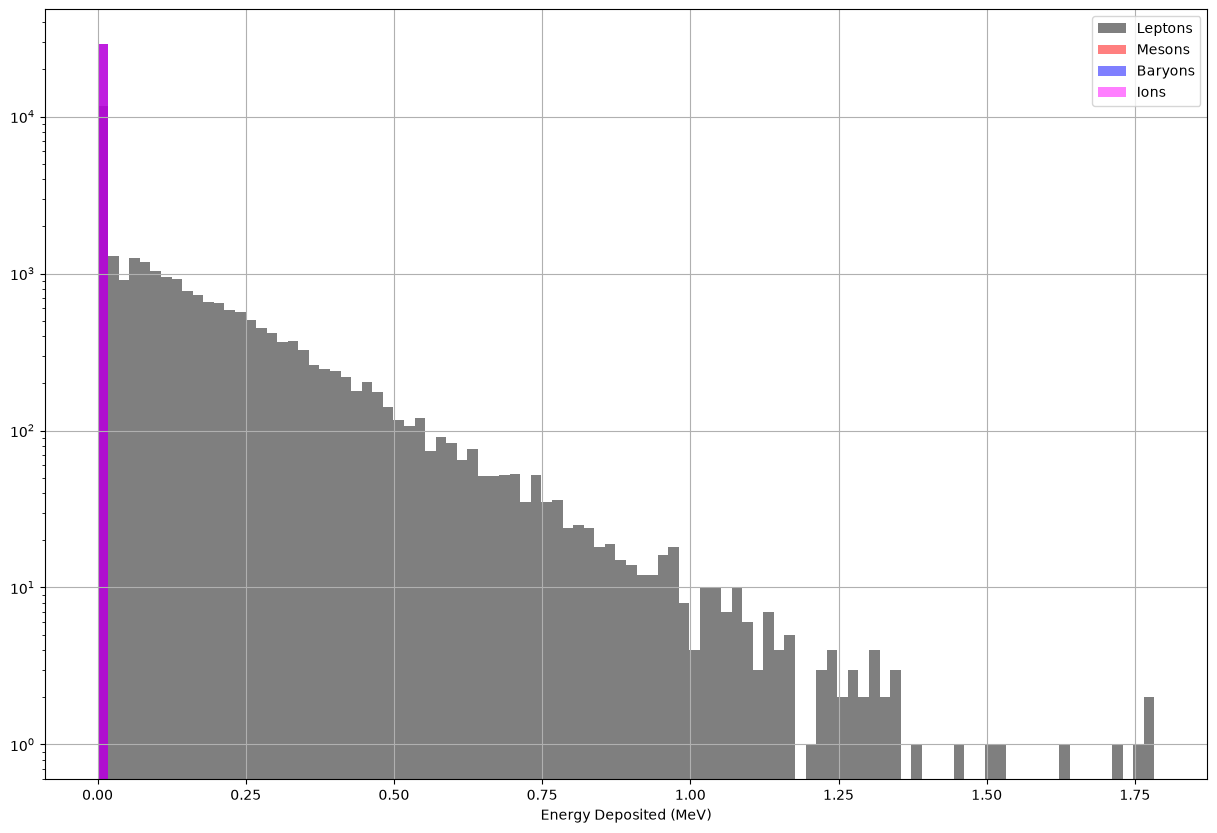

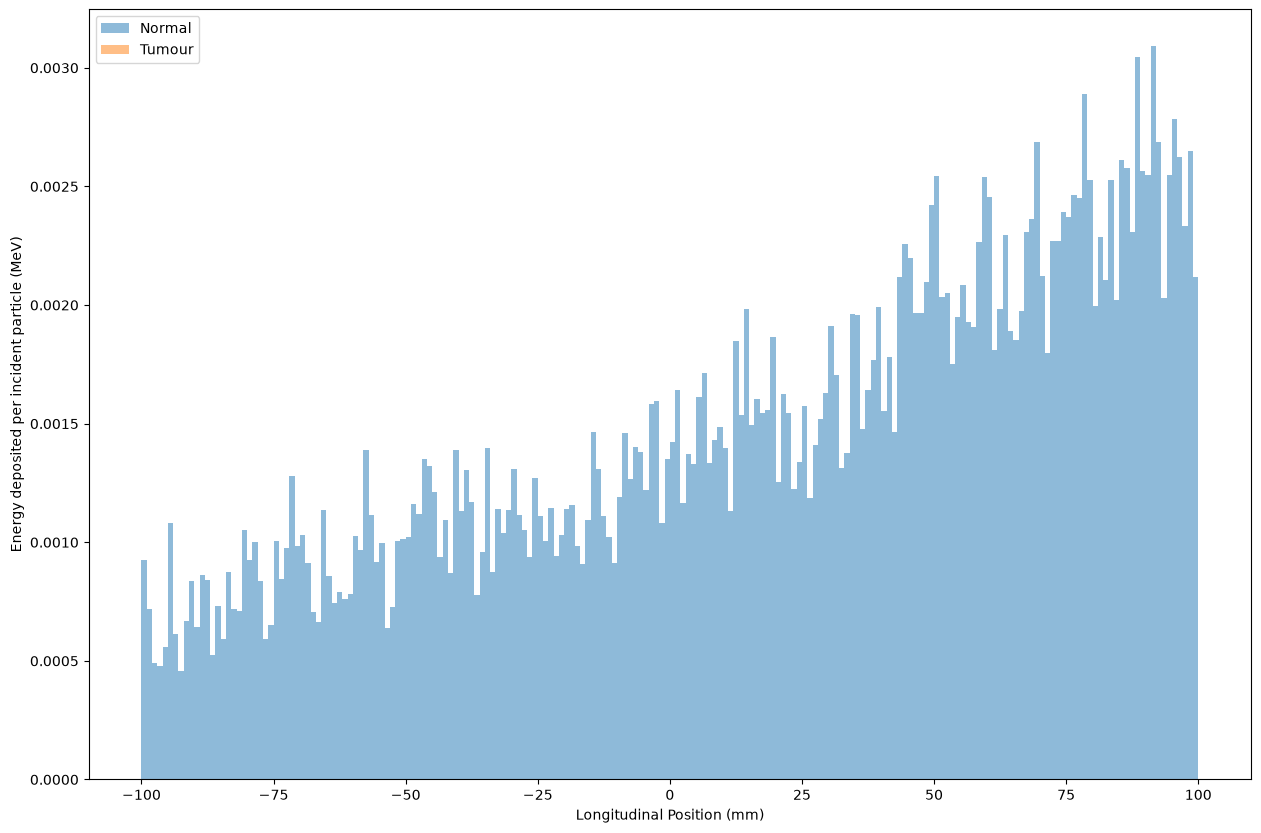

Mean energy deposited per voxel in longitudinal direction  0.0014851355665026998 MeV per voxel
TNR is  0.0


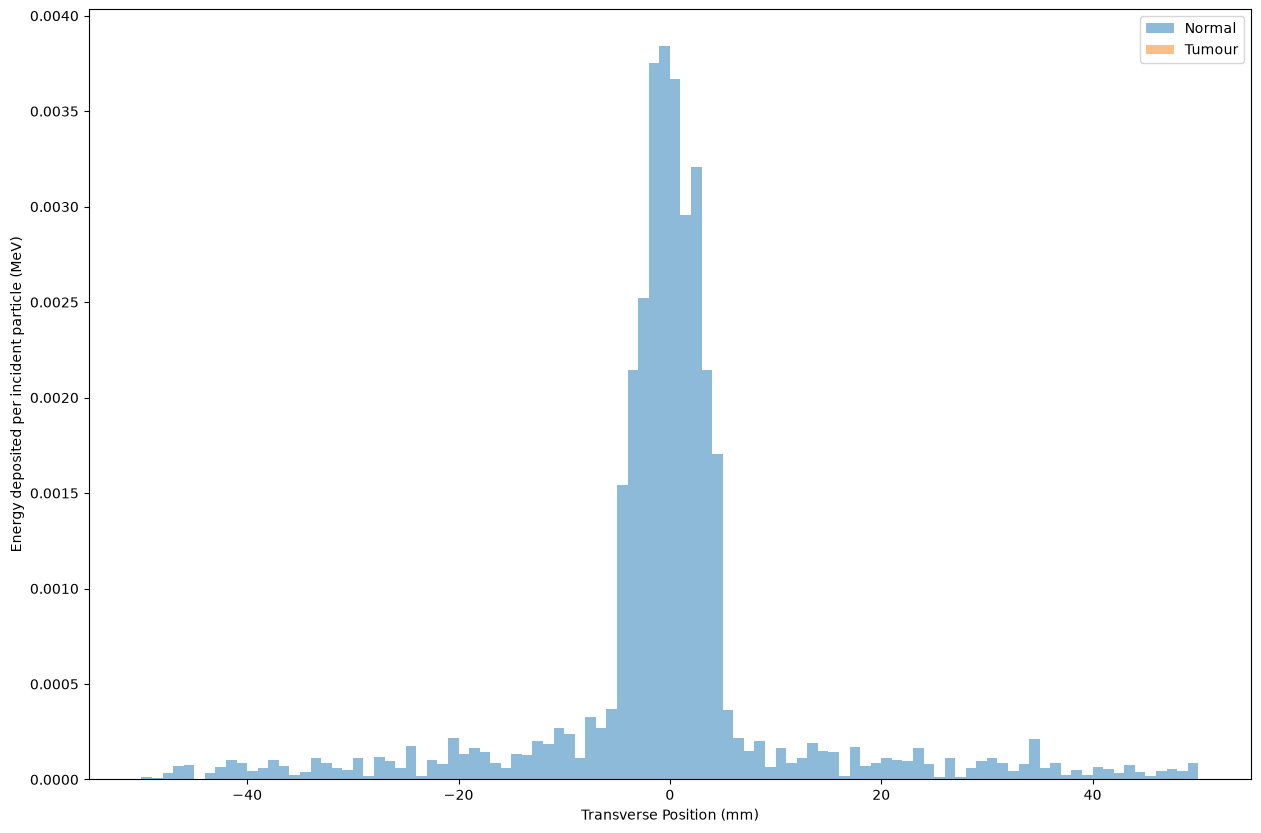

Mean energy deposited per voxel in transverse direction  0.0003680625099286 MeV per voxel


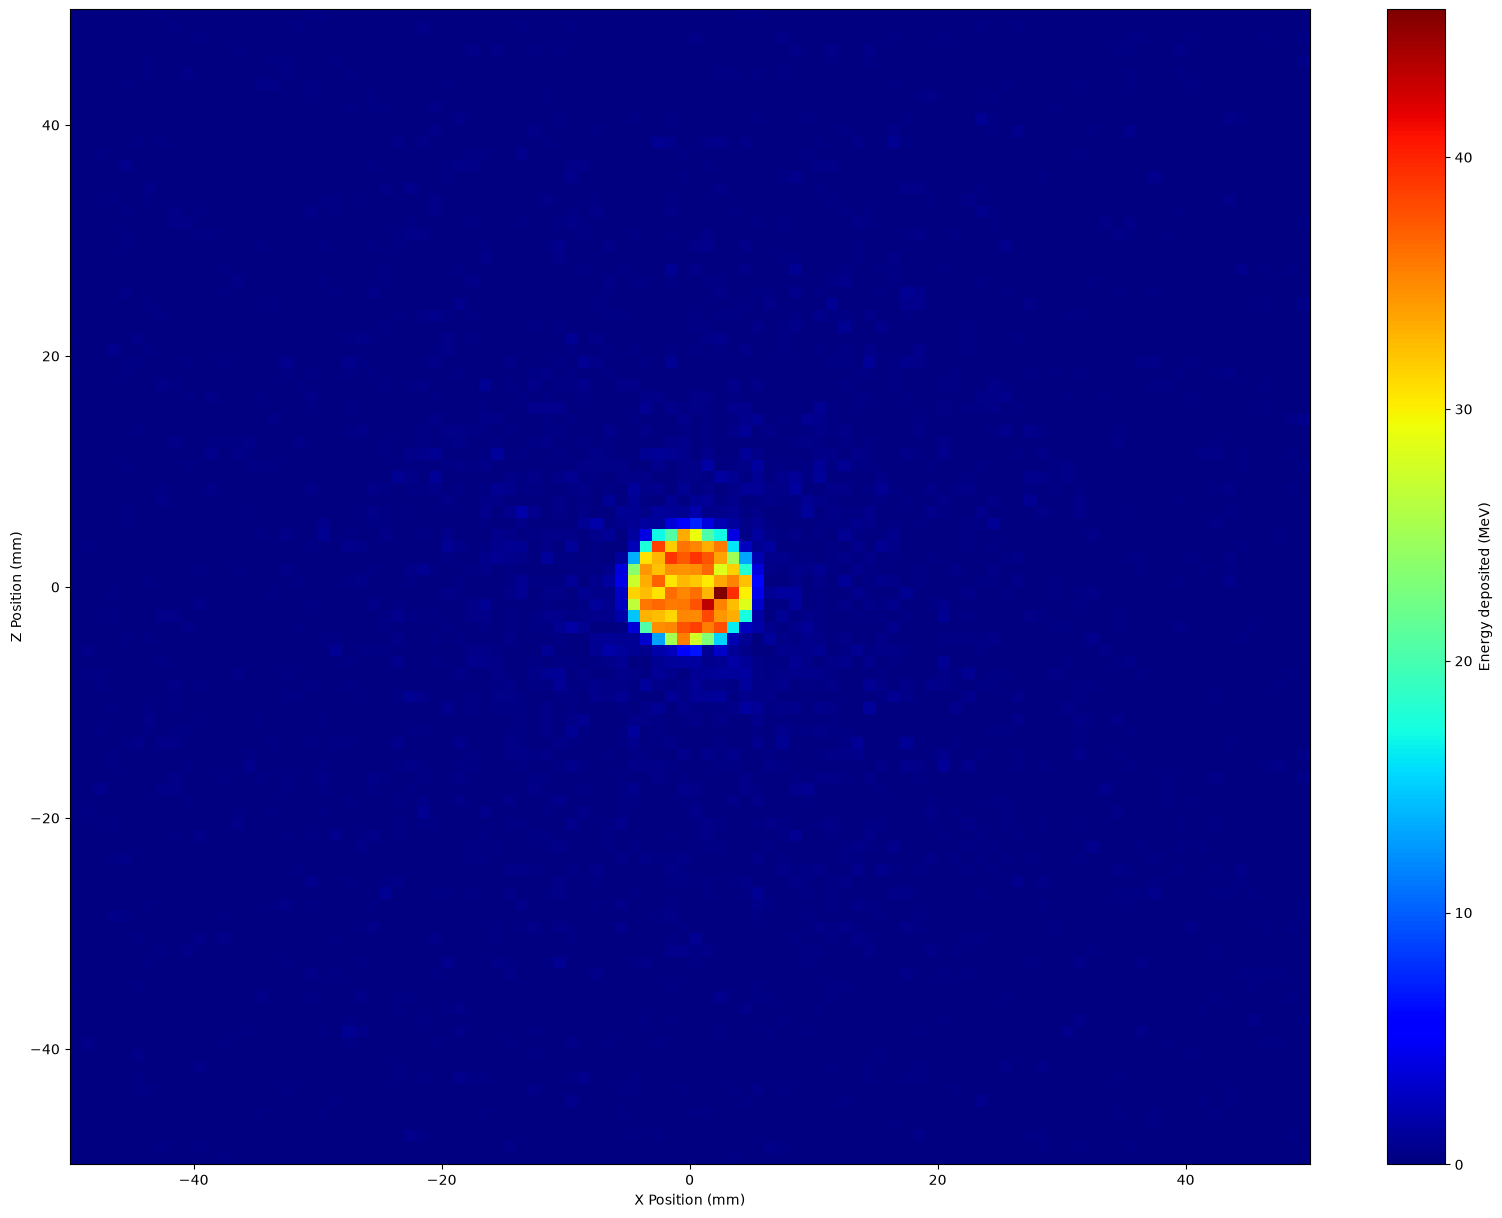

In [ ]:
# First set your file name here.
gamma_1MeV_fname = './data/DoseMC_gamma_1MeV_10000n_Out.csv'

# Then read in and process the data.
dataframe, intnev, particle, energy, bins, rangemin, rangemax = read_process_csv(gamma_1MeV_fname)

# Remove zero-deposition voxels for the profile plots and particle summary.
filterframe = dataframe[dataframe['Total'] > 0]
tag = simulation_tag(gamma_1MeV_fname)

calculate_energy_by_particle(filterframe, intnev, particle, energy)
plot_components_as_hist(filterframe, nbins=100, savefig=True, tag=tag)
plot_longitudinal_profile(
    filterframe, bins, rangemin, rangemax, intnev, savefig=True, tag=tag
)
plot_transverse_profile(
    filterframe, bins, rangemin, rangemax, intnev, savefig=True, tag=tag
)
plot_2d_transpose_profile(
    filterframe, bins, rangemin, rangemax, savefig=True, tag=tag
)


### 1.4 Investigating the Energy Dependence of Gamma-ray Interactions

Co-60 sources produce gamma rays with energies of 1.173 and 1.333 MeV. Accelerator-based radiotherapy produces higher-energy gamma-ray beams through bremsstrahlung.

Run the following simulations:

```bash
runDoseProfile.py gamma 5 10000 0 0
runDoseProfile.py gamma 10 10000 0 0
runDoseProfile.py gamma 50 10000 0 0
```

Analyse each output using the same functions as for the 1 MeV beam. The expected files are `DoseMC_gamma_5MeV_10000n_Out.csv`, `DoseMC_gamma_10MeV_10000n_Out.csv` and `DoseMC_gamma_50MeV_10000n_Out.csv`.

**Questions**

1. What conclusions can be drawn about Co-60 sources and accelerator-based gamma-ray technology?
2. How does the nature of the underlying physical interactions change as the beam energy increases?
3. What other factors should be considered when assessing the advantages and limitations of accelerator-based technology?


In [ ]:
# your code here
# Hint: repeat the Section 1.3 analysis for the 5 MeV gamma-ray data.


In [ ]:
# your code here
# Hint: repeat the Section 1.3 analysis for the 10 MeV gamma-ray data.


In [ ]:
# your code here
# Hint: repeat the Section 1.3 analysis for the 50 MeV gamma-ray data.


***
## <b>Part Two: Deposited Energy, Absorbed Dose and Equivalent Dose</b>
***

The stochastic effect in terms of cell damage as a result of exposure to ionising radiation is characterised by the <b>equivalent dose $H$ </b>measured in Sieverts (Sv). The equivalent dose absorbed in tissue is defined such that

$$H = \sum_R W_R D,$$

where $W_R$ is a weighting factor for radiation type $R$, a measure of the relative biological effectiveness of the radiation type. Nominal values of $W_R$ for different particle types as set by the International Committee for Radiation Protection (ICRP) are:

<div align="center">

| Radiation Type | $W_R$ |
|---|---|
| lepton | 1.0 |
| meson | 2.0 |
| baryon | 2.0 |
| ion | 20.0 |

</div>

The <b>absorbed dose $D$</b> is defined as the mean energy deposited by ionising radiation in matter ($E_d$) per unit mass, the unit of which is the Gray (J/kg):

$$D = \frac{E_d}{m}$$

The simulation records the energy deposited in a given volume element (or voxel) of the phantom. The header variables in the CSV files give the voxel dimensions, with the minimum and maximum coordinates in mm.

For the longitudinal dose profile, voxels are combined in such a way to create individual slices of volume lying along the beam direction and the mean energy per slice is output. Using the Jupyter notebook, calculate the volume of each slice used in the longitudinal dose profile calculation which gives the result called mean energy deposited per voxel. Note that the slice calculation uses `filterframe`, not `cutframeL`.

After analysing the 1, 5, 10 and 50 MeV gamma-ray files in Part One, use the dose function in Section 2.1 to calculate the total absorbed dose ($D$) and equivalent dose ($H$) per incident beam particle for each energy.

How many 10 MeV gamma-rays would a patient need to be exposed to achieve an absorbed dose of 50 Gy in this volume?

Looking at the 2D distribution of x-z energy deposits, estimate a rectangle which contains the core of the energy deposited by the beam. Create a new cell in your notebook which filters the dataframe to select only these voxels and use this to recalculate $D$ and $H$. For example:

```python
newframe = filterframe[
    (filterframe['zpos'].abs() < 10) &
    (filterframe['xpos'].abs() < 10)
]
```

Please modify the Python cells to perform these calculations and compare the full-phantom and beam-core results.

### 2.1 Calculating Absorbed and Equivalent Dose

The deposited energy can be converted into absorbed dose using the mass of the selected water volume. Equivalent dose also includes the radiation weighting factor for each particle type.

**Questions**

1. What are the dimensions and volume of one voxel?
2. What are the mass of one voxel and the total mass of the selected volume?
3. How do the absorbed and equivalent doses change as the incident gamma-ray energy increases?
4. How many 10 MeV gamma rays would be needed to deliver an absorbed dose of 50 Gy to this volume?


In [ ]:
# your code here
# Hint: calculate absorbed dose from deposited energy and mass, then include the radiation weighting factors for equivalent dose.
# Hint: compare the four gamma-ray energies and determine the number of 10 MeV particles needed for 50 Gy.


### 2.2 Dose in the Central Beam Region

Use the transverse energy-deposition plot to estimate a rectangular region containing the main beam core. Filter the dataframe to select only voxels in this region and recalculate the dose.

**Questions**

1. Does restricting the calculation to the beam core increase the dose as expected?
2. Why does the dose change when only the beam-core voxels are included?
3. How do the full-phantom and beam-core absorbed and equivalent doses compare?


In [ ]:
# your code here
# Hint: use the transverse distribution to select a rectangular beam-core region, then compare its dose with the full phantom.


***
## <b>Part Three: Electromagnetic Interactions of Heavy Charged Particles</b>
***

Electromagnetic energy loss for heavy charged particles is dominated by the ionisation process as described by the <b>Bethe-Bloch equation</b>, in which the ionisation density is related to the charge, mass and velocity of the incident particle. As the particle slows, the cross section for interactions with atomic electrons increases leading to higher and higher energy loss until the particle comes to rest. It is this behaviour, characterised by the presence of a <b>Bragg peak</b> in the dose distribution for heavy charged particles, that has led to intense interest in proton and ion radiotherapy in recent years.

In order to demonstrate the significant difference between gamma-ray and hadron radiotherapy, we are going to run the simulation with beams of protons and carbon ions. As before, let's simulate and extract the dose distributions for proton beams with kinetic energies of 100, 500 and 1000 MeV. Now let's do the same for ion beams of 500, 1000 and 2000 MeV.

By looking at the resultant plots, what can you conclude about the nature of the energy deposit for hadron beams? What can you say about the range of the charged particles in the water phantom, and how might this be exploited in cancer treatment? How does the longitudinal and transverse dose profile differ from the gamma-ray data? Comment on the typical length scale (i.e. FWHM) associated with the Bragg peaks for protons and ions of the same energy. What implications does this latter observation have in terms of treatment planning?

### 3.1 Analysis of Proton and Ion Beams

Use the functions from Section 1.2 to analyse the proton and carbon-ion simulations. Compare the longitudinal and transverse profiles with the gamma-ray results.

**Questions**

1. Where is the Bragg peak for each beam, and how does its position vary with beam energy?
2. What are the approximate particle range, peak height, and full width at half maximum (FWHM)?
3. How do the proton and ion profiles differ at comparable energies?
4. What are the implications of these differences for treatment planning?


In [ ]:
# your code here
# Hint: analyse the longitudinal and transverse profiles for the proton and ion beams, then estimate the Bragg-peak position, range, height and FWHM.


***
## <b>Part Four: Realistic Radiotherapy Simulations with Hadronic Interactions</b>
***

## Part Four: Realistic Radiotherapy Simulations with Hadronic Interactions

The previous investigations focused on electromagnetic interactions. Include hadronic interactions to investigate secondary particle production and its effect on dose distributions.

Add a 1 cm diameter spherical tumour at the centre of the phantom by setting the tumour flag to 1. For example:

```bash
runDoseProfile.py gamma 1 10000 1 0
```

The tumour columns in the CSV files record energy deposited in this sphere; the remaining columns describe the surrounding normal tissue. The tumour-to-normal dose ratio is defined as:

$$\mathrm{TNR} = \frac{D_{\mathrm{tumour}}}{D_{\mathrm{healthy}}}$$

After identifying optimised beam energies, enable hadronic interactions and repeat the simulations. For example:

```bash
runDoseProfile.py gamma 1 10000 1 1
```

This changes the Geant4 physics configuration from `standard_opt3` to `QGSP_BIC_EMY`.

**Questions**

1. What are hadronic interactions, and why can they increase the deposited dose?
2. Which beam energy maximises the TNR for each beam type when hadronic interactions are disabled?
3. How does the fraction of energy deposited by each particle type change for the optimised beam cases?
4. How do the dose distributions change when hadronic interactions are enabled?
5. Which beam type is affected most by hadronic interactions, and why?
6. How do secondary particles contribute to the dose magnitudes and spatial distributions?


### 4.1 Tumour-to-Normal Dose Ratio

Run the tumour simulations for the selected beam types and energies, with and without hadronic interactions. Use the tumour and normal-tissue columns to calculate the dose ratio.

**Questions**

1. Which energy maximises the TNR for each beam type?
2. Does the tumour receive substantially more dose than the surrounding normal tissue?
3. What changes when hadronic interactions are enabled?
4. How do secondary particles affect the tumour and normal-tissue dose distributions?


In [ ]:
# your code here
# Hint: use the tumour and normal-tissue energy deposits to calculate and compare TNR for different beam types, energies and hadronic settings.
